In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
# Load the unified dataset – it's an Excel file, not CSV
df = pd.read_excel('../data/raw/ethiopia_fi_unified_data.xlsx')
ref = pd.read_excel('../data/raw/reference_codes.xlsx')
print('Main data shape:', df.shape)
df.head(3)

Main data shape: (43, 34)


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN


In [3]:
# Record types
print('Record types:\n', df['record_type'].value_counts())
print('\nPillars:\n', df['pillar'].value_counts())
print('\nIndicator codes:\n', df['indicator_code'].unique())
print('\nEvent categories:\n', df[df['record_type']=='event']['category'].value_counts())

Record types:
 record_type
observation    30
event          10
target          3
Name: count, dtype: int64

Pillars:
 pillar
ACCESS           16
USAGE            11
GENDER            5
AFFORDABILITY     1
Name: count, dtype: int64

Indicator codes:
 <ArrowStringArray>
[     'ACC_OWNERSHIP',     'ACC_MM_ACCOUNT',         'ACC_4G_COV',
     'ACC_MOBILE_PEN',          'ACC_FAYDA',      'USG_P2P_COUNT',
      'USG_P2P_VALUE',      'USG_ATM_COUNT',      'USG_ATM_VALUE',
      'USG_CROSSOVER', 'USG_TELEBIRR_USERS', 'USG_TELEBIRR_VALUE',
    'USG_MPESA_USERS',   'USG_MPESA_ACTIVE',    'USG_ACTIVE_RATE',
    'AFF_DATA_INCOME',        'GEN_GAP_ACC',       'GEN_MM_SHARE',
     'GEN_GAP_MOBILE',       'EVT_TELEBIRR',      'EVT_SAFARICOM',
          'EVT_MPESA',          'EVT_FAYDA',      'EVT_FX_REFORM',
      'EVT_CROSSOVER',  'EVT_MPESA_INTEROP',       'EVT_ETHIOPAY',
          'EVT_NFIS2',   'EVT_SAFCOM_PRICE']
Length: 29, dtype: str

Event categories:
 category
product_launch    2
infrastruct

In [4]:
# Convert observation_date to datetime
df['observation_date'] = pd.to_datetime(df['observation_date'], errors='coerce')

# Observations over time
obs = df[df['record_type']=='observation'].copy()
obs['year'] = obs['observation_date'].dt.year
print('Observations by year and indicator:')
print(obs.groupby(['year','indicator_code']).size().unstack(fill_value=0))

Observations by year and indicator:
indicator_code  ACC_4G_COV  ACC_FAYDA  ACC_MM_ACCOUNT  ACC_MOBILE_PEN  \
year                                                                    
2014                     0          0               0               0   
2017                     0          0               0               0   
2021                     0          0               1               0   
2023                     1          0               0               0   
2024                     0          1               1               0   
2025                     1          2               0               1   

indicator_code  ACC_OWNERSHIP  AFF_DATA_INCOME  GEN_GAP_ACC  GEN_GAP_MOBILE  \
year                                                                          
2014                        1                0            0               0   
2017                        1                0            0               0   
2021                        3                0            1    

In [5]:
# Confidence distribution
print('Confidence levels:\n', df['confidence'].value_counts())

# Missing values in key columns
print('\nMissing values:\n', df[['value_numeric','indicator_code','source_url','original_text']].isnull().sum())

Confidence levels:
 confidence
high      40
medium     3
Name: count, dtype: int64

Missing values:
 value_numeric     10
indicator_code     0
source_url        12
original_text     10
dtype: int64


In [6]:
new_records = []
# Example: Add an observation for mobile money agents in 2024
new_records.append({
    'record_type': 'observation',
    'pillar': 'Usage',
    'indicator': 'Mobile Money Agents (per 100,000 adults)',
    'indicator_code': 'INF_AGENT_DENSITY',
    'value_numeric': 85,  # replace with real data
    'observation_date': '2024-12-31',
    'source_name': 'GSMA SOTIR 2025',
    'source_url': 'https://www.gsma.com/sotir',
    'original_text': 'Ethiopia had 85 agents per 100,000 adults in 2024.',
    'confidence': 'medium',
    'collected_by': 'Meron T. Gebru',
    'collection_date': '2026-07-17',
    'notes': 'Added for infrastructure analysis.'
})
# Convert to DataFrame and append to main df
new_df = pd.DataFrame(new_records)
df_enriched = pd.concat([df, new_df], ignore_index=True)
print('Enriched dataset shape:', df_enriched.shape)
# Save enriched dataset
df_enriched.to_csv('../data/processed/enriched_data.csv', index=False)

Enriched dataset shape: (44, 34)


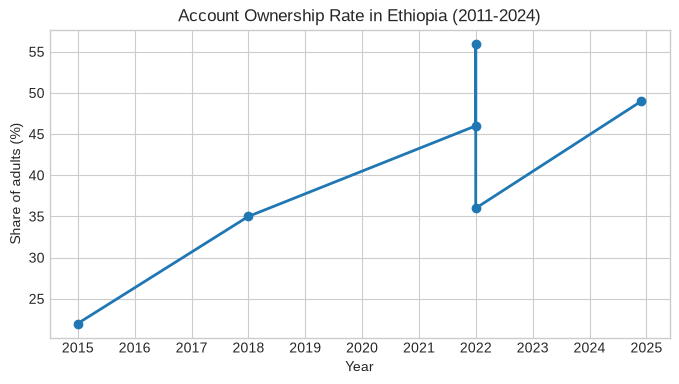

In [7]:
acc = obs[obs['indicator_code']=='ACC_OWNERSHIP'].sort_values('observation_date')
plt.figure(figsize=(8,4))
plt.plot(acc['observation_date'], acc['value_numeric'], marker='o', linewidth=2)
plt.title('Account Ownership Rate in Ethiopia (2011-2024)')
plt.ylabel('Share of adults (%)')
plt.xlabel('Year')
plt.grid(True)
plt.savefig('../reports/figures/account_ownership.png', dpi=150)
plt.show()

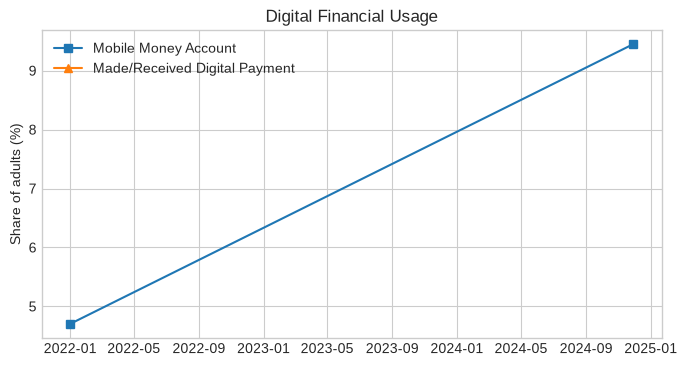

In [8]:
# Mobile money accounts
mm = obs[obs['indicator_code']=='ACC_MM_ACCOUNT']
digital = obs[obs['indicator_code']=='USG_DIGITAL_PAYMENT']
plt.figure(figsize=(8,4))
plt.plot(mm['observation_date'], mm['value_numeric'], marker='s', label='Mobile Money Account')
plt.plot(digital['observation_date'], digital['value_numeric'], marker='^', label='Made/Received Digital Payment')
plt.legend()
plt.title('Digital Financial Usage')
plt.ylabel('Share of adults (%)')
plt.savefig('../reports/figures/digital_usage.png', dpi=150)
plt.show()

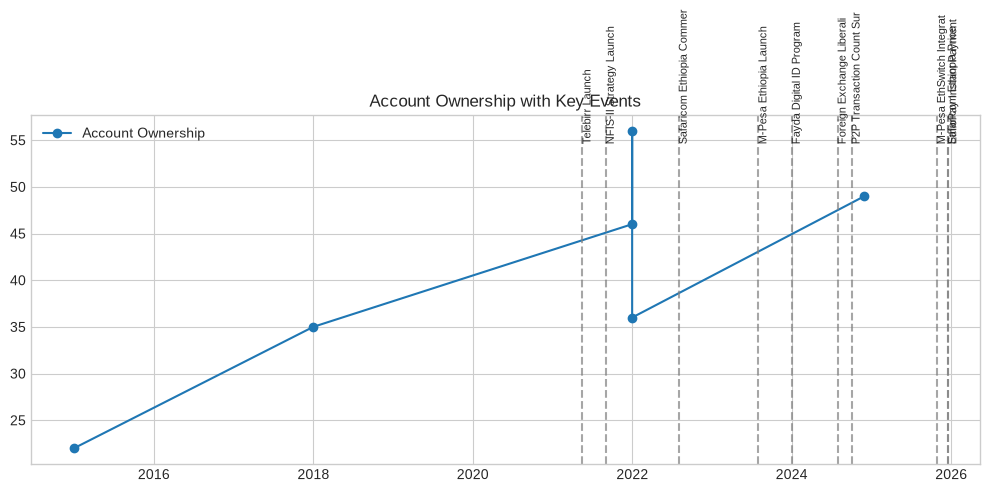

In [11]:
# Filter events and use 'observation_date' as the date column
events = df_enriched[df_enriched['record_type'] == 'event'].copy()
events['event_date'] = pd.to_datetime(events['observation_date'])

# Plot account ownership with events
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(acc['observation_date'], acc['value_numeric'], marker='o', label='Account Ownership')
for _, ev in events.iterrows():
    ax.axvline(ev['event_date'], color='gray', linestyle='--', alpha=0.7)
    # Use event_name if available; otherwise fall back to a generic label
    label = ev.get('event_name', ev.get('indicator', f"Event {ev['record_id']}"))[:25]
    ax.text(ev['event_date'], ax.get_ylim()[1] * 0.95, label, rotation=90, fontsize=8)
ax.set_title('Account Ownership with Key Events')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/events_timeline.png', dpi=150)
plt.show()

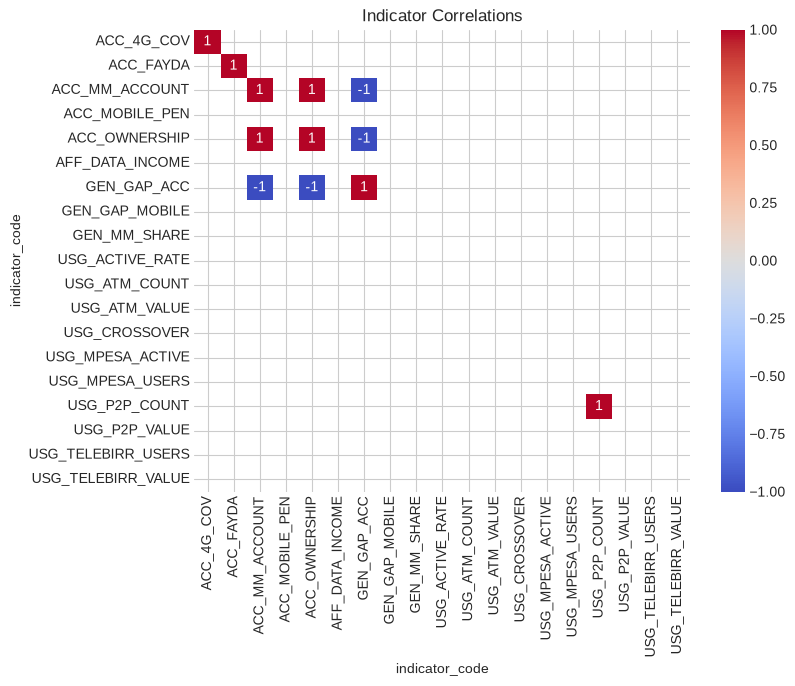

In [10]:
# Pivot indicators to wide format
wide = obs.pivot_table(index='observation_date', columns='indicator_code', values='value_numeric')
# Compute correlations (drop rows with many NaNs)
corr = wide.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Indicator Correlations')
plt.savefig('../reports/figures/correlation_heatmap.png', dpi=150)
plt.show()